In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F

import numpy as np
import xtrack as xt
import xpart as xp
import xobjects as xo
import xplt
import matplotlib.pyplot as plt
import scienceplots
plt.style.use(['science', 'no-latex'])
import pickle
from datetime import datetime
from models import *

from scipy import stats
from torch.utils.data import TensorDataset, DataLoader
from torchinfo import summary

torch.set_default_dtype(torch.float64)

/home/mremta/vscode/pinn-project/venv/lib/python3.10/site-packages/xplt/hooks.py:31: RuntimeWarning: Failed to register formatters with pint: No module named 'pint'
  warnings.warn(f"Failed to register formatters with pint: {e}", RuntimeWarning)


In [3]:
def init_weights_glorot(m):
    if isinstance(m, nn.Linear):
        nn.init.xavier_normal_(m.weight)
        if m.bias is not None:
            nn.init.zeros_(m.bias)

def normalize(x, minimum=None, maximum=None):
    if minimum is None:
        minimum = x.min()
    if maximum is None:
        maximum = x.max()
    return (x - minimum) / (maximum - minimum)

## Data preparation

In [3]:
inputs = []
targets = []

for parameter in [0.5095, 0.61, 0.71]:
    with open(f'data/simple_line_10k_perturbed_{parameter}.pkl', 'rb') as f:
        data = pickle.load(f)
        tmp_inputs = torch.tensor(np.array([data[0][:, :-1], data[1][:, :-1], data[2][:, 1:], data[3][:, 1:]]))
        tmp_inputs = tmp_inputs.reshape(tmp_inputs.shape[0], tmp_inputs.shape[1] * tmp_inputs.shape[2])
        inputs.append(tmp_inputs)
        tmp_targets = torch.tensor(np.array([data[0][:, 1:], data[1][:, 1:]]))
        tmp_targets = tmp_targets.reshape(tmp_targets.shape[0], tmp_targets.shape[1] * tmp_targets.shape[2])
        targets.append(tmp_targets)

inputs = torch.cat(inputs, dim=1).permute(1, 0)
targets = torch.cat(targets, dim=1).permute(1, 0)

inputs_test = []
targets_test = []

for parameter in [0.57, 0.68]:
    with open(f'data/simple_line_10k_perturbed_{parameter}.pkl', 'rb') as f:
        data = pickle.load(f)
        tmp_inputs = torch.tensor(np.array([data[0][:, :-1], data[1][:, :-1], data[2][:, 1:], data[3][:, 1:]]))
        tmp_inputs = tmp_inputs.reshape(tmp_inputs.shape[0], tmp_inputs.shape[1] * tmp_inputs.shape[2])
        inputs_test.append(tmp_inputs)
        tmp_targets = torch.tensor(np.array([data[0][:, 1:], data[1][:, 1:]]))
        tmp_targets = tmp_targets.reshape(tmp_targets.shape[0], tmp_targets.shape[1] * tmp_targets.shape[2])
        targets_test.append(tmp_targets)

inputs_test = torch.cat(inputs_test, dim=1).permute(1, 0)
targets_test = torch.cat(targets_test, dim=1).permute(1, 0)

In [4]:
minimum_list = []
maximum_list = []

for i in range(inputs.shape[1]):
    minimum = inputs[:, i].min()
    maximum = inputs[:, i].max()

    minimum_list.append(minimum)
    maximum_list.append(maximum)

    inputs[:, i] = normalize(inputs[:, i], minimum, maximum)
    inputs_test[:, i] = normalize(inputs_test[:, i], minimum, maximum)
    if i < targets.shape[1]:
        targets[:, i] = normalize(targets[:, i], minimum, maximum)
        targets_test[:, i] = normalize(targets_test[:, i], minimum, maximum)

In [ ]:
np.random.seed(144) 
idx_train = np.random.binomial(1, 0.01, inputs.shape[0]).astype(np.bool) # subsample 1 %
inputs_train = inputs[idx_train, :] 
targets_train = targets[idx_train, :]


torch.save((inputs_train, targets_train, minimum_list, maximum_list), 'data/data_train_simple_line_henonnet.pt')
torch.save((inputs_test, targets_test, minimum_list, maximum_list), 'data_test_simple_line_henonnet.pt')

## Training

In [13]:
inputs_train, targets_train, _, _ = torch.load('data/data_train_simple_line_henonnet.pt')

train_set = TensorDataset(inputs_train, targets_train)
train_loader = DataLoader(train_set, batch_size=256, shuffle=True)

#test_set = TensorDataset(inputs_test, targets_test)
#test_loader = DataLoader(test_set, batch_size=256, shuffle=True)

In [14]:
henon_layers = 8
input_dim = 2
context_dim = 2

context_nets = []
for i in range(henon_layers):
    context_nets.append(MLP(input_dim//2 + context_dim, [16, 16, 16], 1, final_bias=False))

model = ConditionalHenonNet(input_dim, context_nets, layers=henon_layers)

model.apply(init_weights_glorot)

ConditionalHenonNet(
  (net): Sequential(
    (0): ConditionalHenonLayer(
      (context_net): MLP(
        (net): Sequential(
          (0): Linear(in_features=3, out_features=16, bias=True)
          (1): Tanh()
          (2): Linear(in_features=16, out_features=16, bias=True)
          (3): Tanh()
          (4): Linear(in_features=16, out_features=16, bias=True)
          (5): Tanh()
          (6): Linear(in_features=16, out_features=1, bias=False)
        )
      )
    )
    (1): ConditionalHenonLayer(
      (context_net): MLP(
        (net): Sequential(
          (0): Linear(in_features=3, out_features=16, bias=True)
          (1): Tanh()
          (2): Linear(in_features=16, out_features=16, bias=True)
          (3): Tanh()
          (4): Linear(in_features=16, out_features=16, bias=True)
          (5): Tanh()
          (6): Linear(in_features=16, out_features=1, bias=False)
        )
      )
    )
    (2): ConditionalHenonLayer(
      (context_net): MLP(
        (net): Sequentia

In [15]:
optimizer = torch.optim.AdamW(model.parameters(), 1e-3)

In [18]:
epochs = 100

model.train()
total_loss_epochs = []
for epoch in range(epochs):
    total_losses = 0.0
    for batch in train_loader:
        optimizer.zero_grad()
        x, y = batch
        
        outputs = model(x)
        
        loss = torch.mean((outputs - y)**2)
        loss.backward()
        optimizer.step()

        total_losses += loss.item()
        
    total_loss_epochs.append(total_losses)
    print(f"Epoch {epoch}: loss = {total_losses / len(train_loader):.8f}")

Epoch 0: loss = 0.00000811
Epoch 1: loss = 0.00000780
Epoch 2: loss = 0.00000825
Epoch 3: loss = 0.00000763
Epoch 4: loss = 0.00000809
Epoch 5: loss = 0.00000831
Epoch 6: loss = 0.00000760
Epoch 7: loss = 0.00000800
Epoch 8: loss = 0.00000745
Epoch 9: loss = 0.00000783
Epoch 10: loss = 0.00000799
Epoch 11: loss = 0.00000744
Epoch 12: loss = 0.00000768
Epoch 13: loss = 0.00000788
Epoch 14: loss = 0.00000756
Epoch 15: loss = 0.00000788
Epoch 16: loss = 0.00000759
Epoch 17: loss = 0.00000759
Epoch 18: loss = 0.00000760
Epoch 19: loss = 0.00000769
Epoch 20: loss = 0.00000755
Epoch 21: loss = 0.00000747
Epoch 22: loss = 0.00000724
Epoch 23: loss = 0.00000753
Epoch 24: loss = 0.00000759
Epoch 25: loss = 0.00000754
Epoch 26: loss = 0.00000764
Epoch 27: loss = 0.00000750
Epoch 28: loss = 0.00000735
Epoch 29: loss = 0.00000763
Epoch 30: loss = 0.00000775
Epoch 31: loss = 0.00000698
Epoch 32: loss = 0.00000775
Epoch 33: loss = 0.00000729
Epoch 34: loss = 0.00000735
Epoch 35: loss = 0.00000750
Ep

In [17]:
optimizer.lr = 1e-4

In [19]:
torch.save(model.state_dict(), 'henonnet_model.pt')

## Evaluation

In [3]:
henon_layers = 8
input_dim = 2
context_dim = 2

context_nets = []
for i in range(henon_layers):
    context_nets.append(MLP(input_dim//2 + context_dim, [16, 16, 16], 1, final_bias=False))

model = ConditionalHenonNet(input_dim, context_nets, layers=henon_layers)

state_dict = torch.load('henonnet_model.pt')

model.load_state_dict(torch.load('henonnet_model.pt'))
model.eval()

ConditionalHenonNet(
  (net): Sequential(
    (0): ConditionalHenonLayer(
      (context_net): MLP(
        (net): Sequential(
          (0): Linear(in_features=3, out_features=16, bias=True)
          (1): Tanh()
          (2): Linear(in_features=16, out_features=16, bias=True)
          (3): Tanh()
          (4): Linear(in_features=16, out_features=16, bias=True)
          (5): Tanh()
          (6): Linear(in_features=16, out_features=1, bias=False)
        )
      )
    )
    (1): ConditionalHenonLayer(
      (context_net): MLP(
        (net): Sequential(
          (0): Linear(in_features=3, out_features=16, bias=True)
          (1): Tanh()
          (2): Linear(in_features=16, out_features=16, bias=True)
          (3): Tanh()
          (4): Linear(in_features=16, out_features=16, bias=True)
          (5): Tanh()
          (6): Linear(in_features=16, out_features=1, bias=False)
        )
      )
    )
    (2): ConditionalHenonLayer(
      (context_net): MLP(
        (net): Sequentia

In [5]:
inputs_test, targets_test, minima , maxima = torch.load('data/data_test_simple_line_sympnet.pt')

In [5]:
test_set = TensorDataset(inputs_test, targets_test)
test_loader = DataLoader(test_set, batch_size=1024, shuffle=False)

In [6]:
# predict entire trajectories iteratively
time_start = datetime.now()
losses = []
coord = []
for i in range(1000): #1000
    with torch.no_grad():
        inputs = inputs_test[i::1000, :]
        outputs = model(inputs)
        coord.append(outputs)
        if i < 999:
            inputs_test[i+1::1000, :2] = outputs

        loss = torch.mean((outputs - targets_test[i::1000, :])**2)
        losses.append(loss)
        #print(loss)

time_end = datetime.now()

print(time_end - time_start)

0:01:51.578259


In [7]:
torch.save((coord, losses), 'data/henonnet_test_results.pt')

In [4]:
test_results = torch.load('data/henonnet_test_results.pt')

In [9]:
mse1 = []
mse2 = []
for i in range(len(test_results[0])):
    mse1.append(torch.mean((test_results[0][i][0:10000, :] - targets_test[i:10000000:1000, :])**2))
    mse2.append(torch.mean((test_results[0][i][10000:, :] - targets_test[i+10000000::1000, :])**2))

In [10]:
# predict one integration step
mse_one_step1 = []
mse_one_step2 = []
for i in range(1000): #1000
    with torch.no_grad():
        inputs = inputs_test[i::1000, :]
        outputs = model(inputs)

        mse_one_step1.append(torch.mean((outputs[0:10000] - targets_test[i::1000, :][0:10000])**2))
        mse_one_step2.append(torch.mean((outputs[10000:] - targets_test[i::1000, :][10000:])**2))

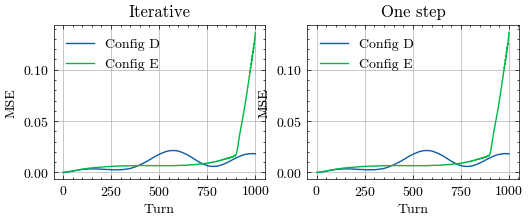

In [11]:
fig, ax = plt.subplots(1, 2, figsize=(6, 2))
ax[0].plot(np.linspace(1, len(mse1)+1, len(mse1)), mse1, label='Config D')
ax[0].plot(np.linspace(1, len(mse2)+1, len(mse2)), mse2, label='Config E')
ax[0].set_xlabel('Turn')
ax[0].set_ylabel('MSE')
ax[0].set_title('Iterative')
ax[0].legend()
ax[0].grid()

ax[1].plot(np.linspace(1, len(mse1)+1, len(mse1)), mse_one_step1, label='Config D')
ax[1].plot(np.linspace(1, len(mse2)+1, len(mse2)), mse_one_step2, label='Config E')
ax[1].set_xlabel('Turn')
ax[1].set_ylabel('MSE')
ax[1].set_title('One step')
ax[1].legend()
ax[1].grid()


fig.savefig('figures/henonnet_loss_evolution.pdf')

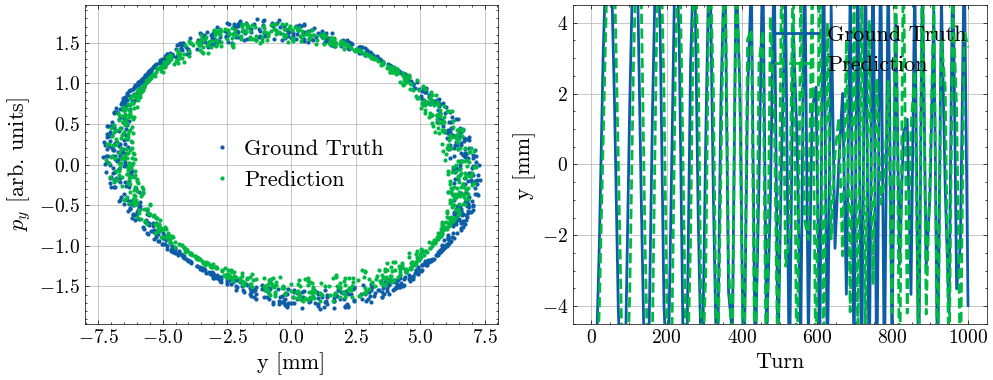

In [10]:
idx = 1
trajectory_y = []
trajectory_py = []
for i in range(len(test_results[0])):
    trajectory_y.append(test_results[0][i][idx, 0])
    trajectory_py.append(test_results[0][i][idx, 1])

trajectory_y = torch.tensor(trajectory_y) * (maxima[0] - minima[0]) + minima[0]
trajectory_py = torch.tensor(trajectory_py) * (maxima[1] - minima[1]) + minima[1]

fig, ax = plt.subplots(1, 2, figsize=(10, 4))
textsize = 16

ax[0].plot((targets_test[1000*idx:1000*(idx+1), 0] * (maxima[0] - minima[0]) + minima[0]) * 1000, (targets_test[1000*idx:1000*(idx+1), 1] * (maxima[1] - minima[1]) + minima[1]) * 1000, 'o', markersize=2, label='Ground Truth')
ax[0].plot(trajectory_y * 1000, trajectory_py * 1000, 'o', markersize=2, label='Prediction')
ax[0].tick_params(axis='both', which='major', labelsize=textsize-2)
ax[0].set_xlabel('y [mm]', fontsize=textsize)
ax[0].set_ylabel(r'$p_y$ [arb. units]', fontsize=textsize)
ax[0].legend(loc='best', handletextpad=0.0, fontsize=textsize)
ax[0].grid()

ax[1].plot(np.linspace(1, trajectory_y.shape[0], trajectory_y.shape[0]//10), trajectory_y[::10] * 1000, linewidth=2, label='Ground Truth')
ax[1].plot(np.linspace(1, trajectory_y.shape[0], trajectory_y.shape[0]//10), (targets_test[1000*idx:1000*(idx+1), 0][::10] * (maxima[0] - minima[0]) + minima[0]) * 1000, '--', linewidth=2, label='Prediction')
ax[1].tick_params(axis='both', which='major', labelsize=textsize-2)
ax[1].set_xlabel('Turn', fontsize=textsize)
ax[1].set_ylabel('y [mm]', fontsize=textsize)
ax[1].set_ylim(-4.5, 4.5)
ax[1].legend(loc='upper right', handletextpad=0.4, fontsize=textsize)
ax[1].grid()

fig.tight_layout()
plt.show()
fig.savefig('figures/henonnet_example_trajectory.pdf')

In [11]:
import pickle
import numpy as np

def action_y(y, py, beta_y, alpha_y):
    gamma_y = (1.0 + alpha_y**2) / beta_y
    return 0.5 * (gamma_y * y**2 + 2.0 * alpha_y * y * py + beta_y * py**2)

J_gt = {}  # keyed by parameter, shape (num_particles, n_turns+1)

with open('data/twiss_parameters.pkl', 'rb') as f:
    beta_y_t, alpha_y_t = pickle.load(f)

# unnormalise data predicted by the model and compute action
idx = 1
trajectory_y = []
trajectory_py = []
for i in range(len(test_results[0])):
    trajectory_y.append(test_results[0][i][idx, 0])
    trajectory_py.append(test_results[0][i][idx, 1])

trajectory_y = torch.tensor(trajectory_y) * (maxima[0] - minima[0]) + minima[0]
trajectory_py = torch.tensor(trajectory_py) * (maxima[1] - minima[1]) + minima[1]

qy_target = 0.57 # 0.68
J_pred = action_y(np.array(trajectory_y), np.array(trajectory_py), beta_y_t[qy_target][1:], alpha_y_t[qy_target][1:])

/tmp/ipykernel_178247/2973185490.py:25: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  J_pred = action_y(np.array(trajectory_y), np.array(trajectory_py), beta_y_t[qy_target][1:], alpha_y_t[qy_target][1:])


In [12]:
ground_truth = (targets_test[1000*idx:1000*(idx+1), 0] * (maxima[0] - minima[0]) + minima[0]), (targets_test[1000*idx:1000*(idx+1), 1] * (maxima[1] - minima[1]) + minima[1])
J_true = action_y(np.array(ground_truth[0]), np.array(ground_truth[1]), beta_y_t[qy_target][1:], alpha_y_t[qy_target][1:])

/tmp/ipykernel_178247/701492288.py:2: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  J_true = action_y(np.array(ground_truth[0]), np.array(ground_truth[1]), beta_y_t[qy_target][1:], alpha_y_t[qy_target][1:])


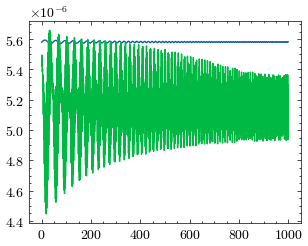

In [13]:
plt.plot(J_true)
plt.plot(J_pred)

In [ ]:
# Generalised: action evolution for ALL trajectories.
# Particle convention in test_results / targets_test:
#   particles 0..9999      -> qy = 0.57
#   particles 10000..19999 -> qy = 0.68

n_turns      = len(test_results[0])           # 1000
n_particles  = test_results[0][0].shape[0]    # 20000
n_per_config = n_particles // 2               # 10000

# Predictions: list of (N,2) per turn -> tensor (n_turns, N, 2) -> (N, n_turns)
pred_stack = torch.stack(test_results[0], dim=0)
pred_y  = (pred_stack[..., 0] * (maxima[0] - minima[0]) + minima[0]).T.numpy()
pred_py = (pred_stack[..., 1] * (maxima[1] - minima[1]) + minima[1]).T.numpy()

# Ground truth: rows are laid out as particle*n_turns + turn -> reshape to (N, n_turns, 2)
gt = targets_test.reshape(n_particles, n_turns, 2)
gt_y  = (gt[..., 0] * (maxima[0] - minima[0]) + minima[0]).numpy()
gt_py = (gt[..., 1] * (maxima[1] - minima[1]) + minima[1]).numpy()

config_map = {0.57: slice(0, n_per_config),
              0.68: slice(n_per_config, n_particles)}

J_pred_all = np.empty_like(pred_y)   # (n_particles, n_turns)
J_true_all = np.empty_like(gt_y)

for qy_target, sl in config_map.items():
    beta  = np.asarray(beta_y_t[qy_target][1:])    # (n_turns,)
    alpha = np.asarray(alpha_y_t[qy_target][1:])
    J_pred_all[sl] = action_y(pred_y[sl], pred_py[sl], beta[None, :], alpha[None, :])
    J_true_all[sl] = action_y(gt_y[sl],   gt_py[sl],   beta[None, :], alpha[None, :])

# sanity check against the single-trajectory example above (idx, qy=0.57)
print('max |J_pred_all[idx] - J_pred|:', np.abs(J_pred_all[idx] - J_pred).max())
print('max |J_true_all[idx] - J_true|:', np.abs(J_true_all[idx] - J_true).max())
